<a href="https://colab.research.google.com/github/sarathkurapati/ml-dl-notebooks/blob/main/ADVANCED_REG_ON_HOUSE_PRICE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [192]:
import pandas as pd
import numpy as np
import seaborn as sns


In [193]:
df=pd.read_csv("train.csv")

In [194]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [195]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [196]:
df.shape

(1460, 81)

In [197]:
df.drop(columns=["Id"],axis=1,inplace=True)

In [198]:
df.fillna(df.mean(),inplace=True)

<ipython-input-198-faa1320c28a3>:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.fillna(df.mean(),inplace=True)


In [199]:
df.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 80, dtype: int64

In [200]:
df.duplicated().sum()

0

In [201]:
df.Alley.unique()

array([nan, 'Grvl', 'Pave'], dtype=object)

In [202]:
df.PoolQC.unique()

array([nan, 'Ex', 'Fa', 'Gd'], dtype=object)

In [203]:
df.Fence.unique()

array([nan, 'MnPrv', 'GdWo', 'GdPrv', 'MnWw'], dtype=object)

In [204]:
df.MiscFeature.unique()

array([nan, 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

In [205]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Alley"]=le.fit_transform(df["Alley"])
df["PoolQC"]=le.fit_transform(df["PoolQC"])
df["Fence"]=le.fit_transform(df["Fence"])
df["MiscFeature"]=le.fit_transform(df["MiscFeature"])
df["MSZoning"]=le.fit_transform(df["MSZoning"])
df["LotShape"]=le.fit_transform(df["LotShape"])
df["Street"]=le.fit_transform(df["Street"])
df["LandContour"]=le.fit_transform(df["LandContour"])
df["SaleType"]=le.fit_transform(df["SaleType"])
df["SaleCondition"]=le.fit_transform(df["SaleCondition"])
df["Utilities"]=le.fit_transform(df["Utilities"])
df["LotConfig"]=le.fit_transform(df["LotConfig"])
df["LandSlope"]=le.fit_transform(df["LandSlope"])
df["Neighborhood"]=le.fit_transform(df["Neighborhood"])
df["Condition1"]=le.fit_transform(df["Condition1"])
df["Condition2"]=le.fit_transform(df["Condition2"])
df["BldgType"]=le.fit_transform(df["BldgType"])
df["HouseStyle"]=le.fit_transform(df["HouseStyle"])
df["RoofStyle"]=le.fit_transform(df["RoofStyle"])
df["RoofMatl"]=le.fit_transform(df["RoofMatl"])
df["Exterior1st"]=le.fit_transform(df["Exterior1st"])
df["Exterior2nd"]=le.fit_transform(df["Exterior2nd"])
df["MasVnrType"]=le.fit_transform(df["MasVnrType"])
df["ExterQual"]=le.fit_transform(df["ExterQual"])
df["ExterCond"]=le.fit_transform(df["ExterCond"])
df["Foundation"]=le.fit_transform(df["Foundation"])
df["BsmtQual"]=le.fit_transform(df["BsmtQual"])
df["BsmtCond"]=le.fit_transform(df["BsmtCond"])
df["BsmtExposure"]=le.fit_transform(df["BsmtExposure"])
df["BsmtFinType1"]=le.fit_transform(df["BsmtFinType1"])
df["BsmtFinSF1"]=le.fit_transform(df["BsmtFinSF1"])
df["BsmtFinType2"]=le.fit_transform(df["BsmtFinType2"])
df["Heating"]=le.fit_transform(df["Heating"])
df["HeatingQC"]=le.fit_transform(df["HeatingQC"])
df["CentralAir"]=le.fit_transform(df["CentralAir"])
df["Electrical"]=le.fit_transform(df["Electrical"])
df["KitchenQual"]=le.fit_transform(df["KitchenQual"])
df["FireplaceQu"]=le.fit_transform(df["FireplaceQu"])
df["GarageType"]=le.fit_transform(df["GarageType"])
df["GarageFinish"]=le.fit_transform(df["GarageFinish"])
df["GarageQual"]=le.fit_transform(df["GarageQual"])
df["GarageQual"]=le.fit_transform(df["GarageQual"])
df["GarageCond"]=le.fit_transform(df["GarageCond"])
df["PavedDrive"]=le.fit_transform(df["PavedDrive"])
df["MiscFeature"]=le.fit_transform(df["MiscFeature"])
df["Functional"]=le.fit_transform(df["Functional"])

In [206]:
df.fillna(df.mean(),inplace=True)

In [207]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450,1,2,3,3,0,4,...,0,3,4,4,0,2,2008,8,4,208500
1,20,3,80.0,9600,1,2,3,3,0,2,...,0,3,4,4,0,5,2007,8,4,181500
2,60,3,68.0,11250,1,2,0,3,0,4,...,0,3,4,4,0,9,2008,8,4,223500
3,70,3,60.0,9550,1,2,0,3,0,0,...,0,3,4,4,0,2,2006,8,0,140000
4,60,3,84.0,14260,1,2,0,3,0,2,...,0,3,4,4,0,12,2008,8,4,250000


In [208]:
df.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 80, dtype: int64

**OUTLIER DETECTION**

<Axes: >

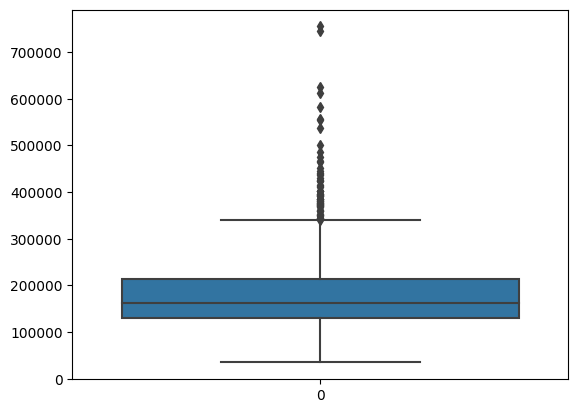

In [209]:
sns.boxplot(df.SalePrice)

<Axes: >

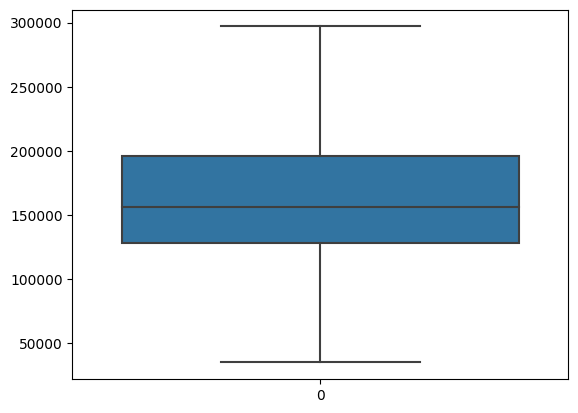

In [230]:
q1 = df.SalePrice.quantile(.25)
q3 = df.SalePrice.quantile(.75)
IQR = q3 - q1
IQR
upper_limit = q3+1.5*IQR
lower_limit = q1-1.5*IQR
upper_limit
df = df[df.SalePrice<upper_limit]
df = df[df.SalePrice<upper_limit]
df = df[df.SalePrice<upper_limit]
df = df[df.SalePrice<upper_limit]
sns.boxplot(df.SalePrice)

In [211]:
x=df.drop(columns='SalePrice',axis=1)
x.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450,1,2,3,3,0,4,...,0,0,3,4,4,0,2,2008,8,4
1,20,3,80.0,9600,1,2,3,3,0,2,...,0,0,3,4,4,0,5,2007,8,4
2,60,3,68.0,11250,1,2,0,3,0,4,...,0,0,3,4,4,0,9,2008,8,4
3,70,3,60.0,9550,1,2,0,3,0,0,...,0,0,3,4,4,0,2,2006,8,0
4,60,3,84.0,14260,1,2,0,3,0,2,...,0,0,3,4,4,0,12,2008,8,4


In [212]:
y=df.SalePrice
y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [213]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((979, 79), (420, 79), (979,), (420,))

In [214]:
X_train =tf.convert_to_tensor(x_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
X_test = tf.convert_to_tensor(x_test, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

ANN REGRESSION

In [215]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [216]:
import tensorflow as tf

In [217]:
# Build an ANN model
reg_model=Sequential()
#ADDING THE INPUT LAYER
reg_model.add(Dense(79,activation="relu"))
#ADDING ONE HIDDEN LAYER
reg_model.add(Dense(64,activation="relu"))
#ADDING 2ND HIDDEN LAYER
reg_model.add(Dense(32,activation="relu"))
#ADDING 3RD HIDDEN LAYER
reg_model.add(Dense(16,activation="relu"))
#ADDING OUTPUT LAYER
reg_model.add(Dense(1,activation="linear"))

In [218]:
#COMPLING THE OUTPUT
reg_model.compile(optimizer="adam",loss="mse")

In [219]:
#FITTING THE MODEL ANN
reg_model.fit(x_train,y_train,batch_size=2,epochs=10)

Epoch 1/10
490/490 [==============================] - 3s 3ms/step - loss: 6530732544.0000
Epoch 2/10
490/490 [==============================] - 1s 3ms/step - loss: 2100249856.0000
Epoch 3/10
490/490 [==============================] - 1s 2ms/step - loss: 1556296576.0000
Epoch 4/10
490/490 [==============================] - 1s 2ms/step - loss: 1285943168.0000
Epoch 5/10
490/490 [==============================] - 1s 2ms/step - loss: 1136855040.0000
Epoch 6/10
490/490 [==============================] - 1s 2ms/step - loss: 1168180608.0000
Epoch 7/10
490/490 [==============================] - 1s 2ms/step - loss: 1074454528.0000
Epoch 8/10
490/490 [==============================] - 1s 2ms/step - loss: 1079497728.0000
Epoch 9/10
490/490 [==============================] - 1s 2ms/step - loss: 1066485696.0000
Epoch 10/10
490/490 [==============================] - 1s 2ms/step - loss: 971512320.0000


In [220]:
y_pred_1=reg_model.predict(x_test)

14/14 [==============================] - 0s 2ms/step


LINEAR REGRESSION

In [221]:
#fitting linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
#evaluation metrics
#MEAN SQUARD ERROR
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mse)
#ROOT MEAN SQUARED ERROR
import numpy as np
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('Root Mean Squared Error:', rmse)
#MEAN ABSOLUTE ERROR
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', mae)

Mean Squared Error: 494603008.23354083
Root Mean Squared Error: 22239.671945276998
Mean Absolute Error: 16346.621739788841


RANDOM FOREST REGRESSION

In [222]:
#Random forest regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train,y_train)

RandomForestRegressor()

In [223]:
y_pred_2=rf.predict(x_test)
#MEAN SQUARD ERROR
from sklearn.metrics import mean_squared_error
mse_2 = mean_squared_error(y_test, y_pred_2)
print('Mean Squared Error:', mse_2)
#ROOT MEAN SQUARED ERROR
import numpy as np
from sklearn.metrics import mean_squared_error
mse_2= mean_squared_error(y_test, y_pred_2)
rmse_2 = np.sqrt(mse_2)
print('Root Mean Squared Error:', rmse_2)
#MEAN ABSOLUTE ERROR
from sklearn.metrics import mean_absolute_error
mae_2 = mean_absolute_error(y_test, y_pred_2)
print('Mean Absolute Error:', mae_2)

Mean Squared Error: 540343132.8992436
Root Mean Squared Error: 23245.28194923098
Mean Absolute Error: 16790.40530952381


DECISION TREE REGRESSION

In [224]:
#DECISION TREE REGRESSOR
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)
y_pred_3 = dt.predict(x_test)
#MEAN SQUARD ERROR
from sklearn.metrics import mean_squared_error
mse_3 = mean_squared_error(y_test, y_pred_3)
print('Mean Squared Error:', mse_3)
#ROOT MEAN SQUARED ERROR
import numpy as np
from sklearn.metrics import mean_squared_error
mse_3= mean_squared_error(y_test, y_pred_3)
rmse_3 = np.sqrt(mse_3)
print('Root Mean Squared Error:', rmse_3)
#MEAN ABSOLUTE ERROR
from sklearn.metrics import mean_absolute_error
mae_3 = mean_absolute_error(y_test, y_pred_3)
print('Mean Absolute Error:', mae_3)

Mean Squared Error: 1071625656.0452381
Root Mean Squared Error: 32735.693914215994
Mean Absolute Error: 23972.35476190476


XG BOOST REGRESION

In [225]:
#xg boost regressor
import xgboost as xgb
xgbr = xgb.XGBRegressor()
xgbr.fit(x_train, y_train)
y_pred_4= xgbr.predict(x_test)
#MEAN SQUARD ERROR
from sklearn.metrics import mean_squared_error
mse_4 = mean_squared_error(y_test, y_pred_4)
print('Mean Squared Error:', mse_4)
#ROOT MEAN SQUARED ERROR
import numpy as np
from sklearn.metrics import mean_squared_error
mse_4= mean_squared_error(y_test, y_pred_4)
rmse_4 = np.sqrt(mse_4)
print('Root Mean Squared Error:', rmse_4)
#MEAN ABSOLUTE ERROR
from sklearn.metrics import mean_absolute_error
mae_4= mean_absolute_error(y_test, y_pred_4)
print('Mean Absolute Error:', mae_4)

Mean Squared Error: 511902050.0
Root Mean Squared Error: 22625.252
Mean Absolute Error: 15955.558
